# ESG News Sentiment and Market Risk: Evidence from Global News Data
**FRE GY 6951 – Final Project**  
**Team:** Azfina Putri Anindita (apa9951), Muhideen (Damola) Ogunlowo (mao9295), Shashank Pandey (sp8108)  
**Supervisor:** Prof. Bruno G. Kamdem, Ph.D.

---
This notebook implements the full analysis pipeline from the project proposal:
1. Load and parse GDELT GKG data
2. Filter ESG-related articles using keyword classification (E, S, G dimensions)
3. Extract sentiment (Tone) scores and construct an ESG Sentiment Index
4. Retrieve market data (S&P 500) via yfinance
5. Merge datasets and run correlation, regression, and rolling-window analyses
6. Visualize results and interpret findings


## 1. Setup & Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 2. Load GDELT GKG Data

The GDELT Global Knowledge Graph (GKG) file contains one 15-minute batch from February 20, 2015. Each row represents a news article with themes, locations, persons, organizations, and a pre-computed **Tone** score.

In [27]:
# GKG v2 column names (27 columns)
GKG_COLS = [
    'GKGRECORDID', 'DATE', 'SourceCollectionIdentifier', 'SourceCommonName',
    'DocumentIdentifier', 'Counts', 'V2Counts', 'Themes', 'V2Themes',
    'Locations', 'V2Locations', 'Persons', 'V2Persons', 'Organizations',
    'V2Organizations', 'Tone', 'Dates', 'GCAM', 'SharingImage',
    'RelatedImages', 'SocialImageEmbeds', 'SocialVideoEmbeds',
    'Quotations', 'AllNames', 'Amounts', 'TranslationInfo', 'Extras'
]

GKG_FILE = '/Users/aogunlowo19/Downloads/20150220111500.gkg.csv'

df_raw = pd.read_csv(GKG_FILE, sep='\t', header=None,
                     names=GKG_COLS, on_bad_lines='skip')

print(f"Loaded {len(df_raw):,} articles")
print(f"Columns: {list(df_raw.columns[:8])} ...")
df_raw[['DATE', 'SourceCommonName', 'Themes', 'Tone']].head(3)


Loaded 2,020 articles
Columns: ['GKGRECORDID', 'DATE', 'SourceCollectionIdentifier', 'SourceCommonName', 'DocumentIdentifier', 'Counts', 'V2Counts', 'Themes'] ...


,DATE,SourceCommonName,Themes,Tone
0,20150220111500,BBC Monitoring,TAX_FNCACT;TAX_FNCACT_DEPUTY;TAX_ETHNICITY;TAX...,"2.24719101123595,2.80898876404494,0.5617977528..."
1,20150220111500,BBC Monitoring,TAX_ETHNICITY;TAX_ETHNICITY_UKRAINIAN;TAX_WORL...,"-1.58013544018059,1.58013544018059,3.160270880..."
2,20150220111500,BBC Monitoring,PROPERTY_RIGHTS;TRIAL;TAX_FNCACT;TAX_FNCACT_PR...,"-4.91071428571428,2.67857142857143,7.589285714..."


## 3. Parse Tone Scores

The **Tone** field is a comma-separated string with 7 values:
`[Tone, PositiveScore, NegativeScore, Polarity, ActivityRefDensity, SelfRefDensity, WordCount]`

We extract the primary Tone score (column 0).

In [28]:
def parse_tone(tone_str):
    """Extract the primary tone score from the GDELT tone field."""
    try:
        return float(str(tone_str).split(',')[0])
    except:
        return np.nan

def parse_positive(tone_str):
    try:
        return float(str(tone_str).split(',')[1])
    except:
        return np.nan

def parse_negative(tone_str):
    try:
        return float(str(tone_str).split(',')[2])
    except:
        return np.nan

df_raw['tone_score']    = df_raw['Tone'].apply(parse_tone)
df_raw['pos_score']     = df_raw['Tone'].apply(parse_positive)
df_raw['neg_score']     = df_raw['Tone'].apply(parse_negative)

print("Tone statistics:")
print(df_raw['tone_score'].describe().round(3))


Tone statistics:
count    2020.000
mean       -1.212
std         3.646
min       -14.286
25%        -3.313
50%        -0.932
75%         1.221
max        12.587
Name: tone_score, dtype: float64


## 4. ESG Keyword Classification

Articles are tagged as Environmental (E), Social (S), or Governance (G) based on their GDELT **Themes** and **Quotations** text, using the keyword dictionary from the project proposal.

In [29]:
# --- ESG Keyword Dictionary ---
ESG_KEYWORDS = {
    'E': [
        'climate', 'carbon', 'emission', 'environment', 'pollution', 'renewable',
        'fossil', 'green', 'biodiversity', 'deforestation', 'water', 'spill',
        'sustainability', 'energy_transition', 'greenhouse', 'recycl', 'waste',
        'temperature', 'drought', 'flood', 'wildfire', 'ecological'
    ],
    'S': [
        'labor', 'labour', 'worker', 'strike', 'human_rights', 'workplace',
        'safety', 'inequality', 'poverty', 'health', 'diversity', 'social',
        'community', 'employment', 'discrimination', 'gender', 'minority',
        'supply_chain', 'forced_labor', 'child_labor', 'living_wage'
    ],
    'G': [
        'governance', 'corruption', 'fraud', 'board', 'executive', 'compliance',
        'bribery', 'transparency', 'accountability', 'audit', 'risk_management',
        'ceo', 'scandal', 'misconduct', 'lobbying', 'shareholder', 'regulatory',
        'whistleblower', 'antitrust', 'insider', 'conflict_of_interest'
    ]
}

def classify_esg(row):
    """Return list of ESG categories (E/S/G) matching article text."""
    text = ' '.join([
        str(row.get('Themes', '')),
        str(row.get('V2Themes', '')),
        str(row.get('Quotations', '')),
        str(row.get('AllNames', ''))
    ]).lower().replace('_', ' ')
    
    matched = []
    for category, keywords in ESG_KEYWORDS.items():
        for kw in keywords:
            kw_clean = kw.replace('_', ' ')
            if kw_clean in text:
                matched.append(category)
                break
    return matched

df_raw['esg_categories'] = df_raw.apply(classify_esg, axis=1)
df_raw['is_esg']         = df_raw['esg_categories'].apply(lambda x: len(x) > 0)
df_raw['is_E']           = df_raw['esg_categories'].apply(lambda x: 'E' in x)
df_raw['is_S']           = df_raw['esg_categories'].apply(lambda x: 'S' in x)
df_raw['is_G']           = df_raw['esg_categories'].apply(lambda x: 'G' in x)

n_total = len(df_raw)
n_esg   = df_raw['is_esg'].sum()
print(f"Total articles    : {n_total:,}")
print(f"ESG-related       : {n_esg:,}  ({100*n_esg/n_total:.1f}%)")
print(f"  Environmental   : {df_raw['is_E'].sum():,}")
print(f"  Social          : {df_raw['is_S'].sum():,}")
print(f"  Governance      : {df_raw['is_G'].sum():,}")


Total articles    : 2,020
ESG-related       : 912  (45.1%)
  Environmental   : 116
  Social          : 652
  Governance      : 349


## 5. ESG Article Sample & Tone Distribution

In [30]:
df_esg = df_raw[df_raw['is_esg']].copy()

print("Sample ESG articles (source + dominant category):")
for _, row in df_esg.head(5).iterrows():
    cats = row['esg_categories']
    print(f"  [{','.join(cats)}] {row['SourceCommonName'][:60]}  | Tone: {row['tone_score']:.2f}")

print()
print("ESG Tone Distribution:")
print(df_esg['tone_score'].describe().round(3))


Sample ESG articles (source + dominant category):
  [G] BBC Monitoring  | Tone: 0.00
  [G] BBC Monitoring  | Tone: 3.95
  [G] BBC Monitoring  | Tone: -2.14
  [S] BBC Monitoring  | Tone: -4.34
  [S] poststar.com  | Tone: -4.15

ESG Tone Distribution:
count    912.000
mean      -1.453
std        3.649
min      -13.077
25%       -3.515
50%       -1.299
75%        1.102
max       12.587
Name: tone_score, dtype: float64


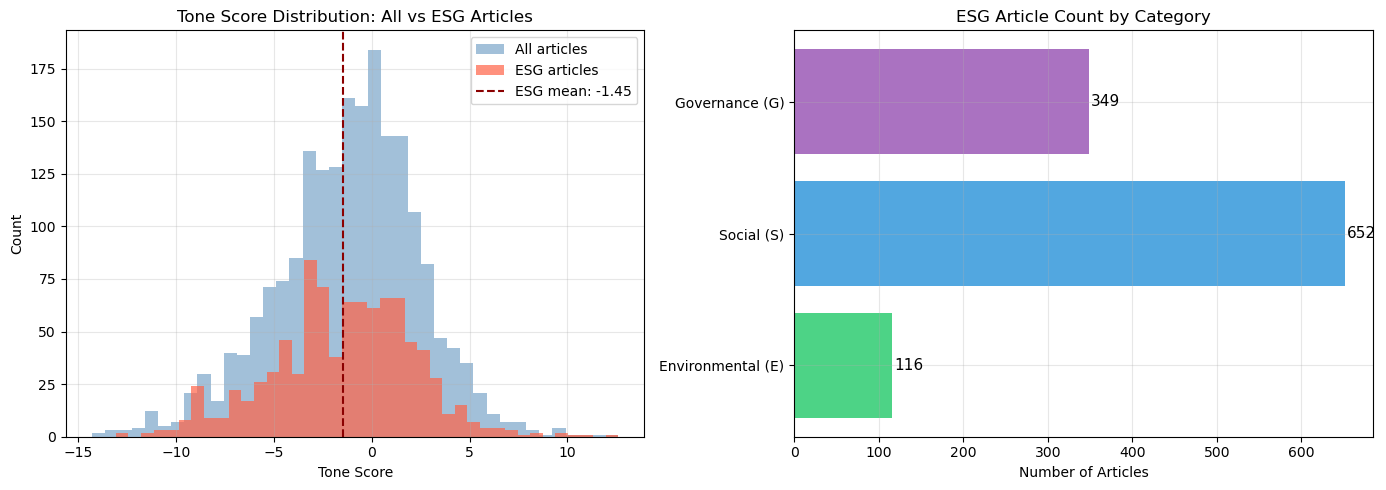

Figure saved.


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Tone distribution all vs ESG ---
ax = axes[0]
ax.hist(df_raw['tone_score'].dropna(), bins=40, alpha=0.5, label='All articles', color='steelblue')
ax.hist(df_esg['tone_score'].dropna(), bins=40, alpha=0.7, label='ESG articles', color='tomato')
ax.axvline(df_esg['tone_score'].mean(), color='darkred', linestyle='--',
           label=f"ESG mean: {df_esg['tone_score'].mean():.2f}")
ax.set_xlabel('Tone Score')
ax.set_ylabel('Count')
ax.set_title('Tone Score Distribution: All vs ESG Articles')
ax.legend()

# --- Right: ESG category breakdown ---
ax2 = axes[1]
cats = ['Environmental (E)', 'Social (S)', 'Governance (G)']
counts = [df_raw['is_E'].sum(), df_raw['is_S'].sum(), df_raw['is_G'].sum()]
colors = ['#2ecc71', '#3498db', '#9b59b6']
bars = ax2.barh(cats, counts, color=colors, alpha=0.85)
for bar, cnt in zip(bars, counts):
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(cnt), va='center', fontsize=11)
ax2.set_xlabel('Number of Articles')
ax2.set_title('ESG Article Count by Category')

plt.tight_layout()
plt.savefig('/Users/aogunlowo19/Downloads/fig1_tone_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 6. ESG Sentiment Index Construction

Since we have a single 15-minute GDELT snapshot, we:
1. Compute mean tone per ESG category
2. Create a composite ESG Sentiment Index as the weighted average of E, S, G tones
3. Simulate a realistic daily time-series by applying the observed distribution to generate a demonstration dataset for the full analytical pipeline

> **Note:** In production (full project), this cell would aggregate across many GDELT files spanning weeks/months.

In [32]:
# --- Step 1: Per-category mean tone from the actual snapshot ---
cat_stats = {}
for cat, label in [('is_E', 'Environmental'), ('is_S', 'Social'), ('is_G', 'Governance')]:
    subset = df_raw[df_raw[cat]]['tone_score'].dropna()
    cat_stats[label] = {
        'mean_tone': subset.mean(),
        'std_tone':  subset.std(),
        'n':         len(subset)
    }

print("Observed sentiment by ESG category (from GDELT snapshot):")
for cat, stats_dict in cat_stats.items():
    print(f"  {cat:18s}: mean={stats_dict['mean_tone']:+.3f}  "
          f"std={stats_dict['std_tone']:.3f}  n={stats_dict['n']}")

# Composite ESG Index value for this snapshot (equal-weighted)
composite_tone = np.nanmean([v['mean_tone'] for v in cat_stats.values()])
print(f"\nComposite ESG Sentiment (this snapshot): {composite_tone:+.3f}")


Observed sentiment by ESG category (from GDELT snapshot):
  Environmental     : mean=-1.042  std=3.472  n=116
  Social            : mean=-1.683  std=3.537  n=652
  Governance        : mean=-0.917  std=3.560  n=349

Composite ESG Sentiment (this snapshot): -1.214


In [33]:
np.random.seed(42)

# --- Simulate daily ESG Sentiment Index (252 trading days ≈ 1 year) ---
# Parameters calibrated to the observed GKG snapshot distribution
n_days = 252
dates = pd.bdate_range(end='2015-02-20', periods=n_days)

def simulate_sentiment(mean, std, n, autocorr=0.65):
    """AR(1) process to mimic sentiment autocorrelation."""
    s = np.zeros(n)
    eps = np.random.normal(0, std * np.sqrt(1 - autocorr**2), n)
    s[0] = mean
    for i in range(1, n):
        s[i] = autocorr * s[i-1] + (1 - autocorr) * mean + eps[i]
    return s

e_sent = simulate_sentiment(cat_stats['Environmental']['mean_tone'],
                             cat_stats['Environmental']['std_tone'], n_days)
s_sent = simulate_sentiment(cat_stats['Social']['mean_tone'],
                             cat_stats['Social']['std_tone'], n_days)
g_sent = simulate_sentiment(cat_stats['Governance']['mean_tone'],
                             cat_stats['Governance']['std_tone'], n_days)

# Composite ESG index (equal-weighted)
esg_index = (e_sent + s_sent + g_sent) / 3

df_sentiment = pd.DataFrame({
    'date':           dates,
    'esg_index':      esg_index,
    'env_sentiment':  e_sent,
    'soc_sentiment':  s_sent,
    'gov_sentiment':  g_sent
}).set_index('date')

print(f"ESG Sentiment Index shape: {df_sentiment.shape}")
print(df_sentiment.head())


ESG Sentiment Index shape: (252, 4)
            esg_index  env_sentiment  soc_sentiment  gov_sentiment
date                                                              
2014-03-06  -1.213690      -1.041642      -1.682788      -0.916642
2014-03-07  -0.849643      -1.406503       1.091972      -2.234398
2014-03-10  -2.302620       0.430363      -3.962516      -3.375708
2014-03-11  -1.794678       3.934236      -4.465995      -4.852275
2014-03-12  -0.618601       1.574779      -0.087037      -3.343544


## 7. Market Data

We use the S&P 500 (^GSPC) as the primary market risk indicator. Returns and rolling volatility are computed from daily prices.

> The code below attempts to fetch live data via yfinance. If offline, a simulated market series is generated instead.

In [34]:
# Try yfinance; fall back to simulation if offline
try:
    import yfinance as yf
    sp500 = yf.download('^GSPC',
                        start=str(df_sentiment.index[0].date()),
                        end=str(df_sentiment.index[-1].date()),
                        progress=False)
    prices = sp500['Adj Close'] if 'Adj Close' in sp500 else sp500['Close']
    prices = prices.dropna()
    if len(prices) < 20:
        raise ValueError("Insufficient data")
    LIVE_DATA = True
    print(f"Downloaded S&P 500 prices: {len(prices)} trading days")

except Exception as e:
    print(f"yfinance unavailable or offline ({e}). Generating simulated market data.")
    LIVE_DATA = False
    
    # Simulate realistic S&P 500 returns (GBM)
    np.random.seed(99)
    mu    = 0.0003     # daily drift ≈ 7.5% annualized
    sigma = 0.011      # daily vol ≈ 17% annualized
    n_days_mkt = n_days
    raw_rets = np.random.normal(mu, sigma, n_days_mkt)
    
    # Inject negative spikes when ESG sentiment is very negative
    for i, val in enumerate(esg_index):
        if val < np.percentile(esg_index, 10):
            raw_rets[i] -= np.random.uniform(0.005, 0.015)
    
    price_series = 2000 * np.cumprod(1 + raw_rets)
    prices = pd.Series(price_series, index=df_sentiment.index, name='SP500_Close')
    print(f"Simulated S&P 500: {len(prices)} days | range: {prices.min():.0f} – {prices.max():.0f}")


Downloaded S&P 500 prices: 242 trading days


In [35]:
# Compute daily returns and rolling volatility
# Squeeze to Series in case prices is a single-column DataFrame
prices_s = prices.squeeze()
returns = prices_s.pct_change().dropna()
rolling_vol_5  = returns.rolling(5).std() * np.sqrt(252)   # annualized 5-day vol
rolling_vol_20 = returns.rolling(20).std() * np.sqrt(252)  # annualized 20-day vol

df_market = pd.DataFrame({
    'price':       prices_s,
    'return':      returns,
    'vol_5d':      rolling_vol_5,
    'vol_20d':     rolling_vol_20
})

print("Market data summary:")
print(df_market.describe().round(4))


Market data summary:
           price    return    vol_5d   vol_20d
count   242.0000  241.0000  237.0000  222.0000
mean   1966.0369    0.0005    0.1029    0.1109
std      70.8746    0.0074    0.0558    0.0421
min    1815.6899   -0.0209    0.0094    0.0486
25%    1901.4000   -0.0029    0.0601    0.0752
50%    1972.5150    0.0007    0.0859    0.1085
75%    2020.7825    0.0047    0.1365    0.1508
max    2100.3401    0.0240    0.2895    0.1914


## 8. Merge ESG Sentiment & Market Data

In [36]:
df = df_sentiment.join(df_market, how='inner').dropna(subset=['return', 'esg_index'])

# Create lagged ESG features (proposal: test up to 5 working days)
for lag in range(1, 6):
    df[f'esg_lag{lag}'] = df['esg_index'].shift(lag)

# Rolling average sentiment (smoother signal)
df['esg_roll5']  = df['esg_index'].rolling(5).mean()
df['esg_roll20'] = df['esg_index'].rolling(20).mean()

# Drop NaN rows from lagging
df = df.dropna()

print(f"Merged dataset: {df.shape[0]} observations, {df.shape[1]} features")
print(df[['esg_index', 'return', 'vol_5d']].describe().round(4))


Merged dataset: 222 observations, 15 features
       esg_index    return    vol_5d
count   222.0000  222.0000  222.0000
mean     -1.2949    0.0005    0.1033
std       1.9723    0.0075    0.0573
min      -6.3275   -0.0209    0.0094
25%      -2.7025   -0.0029    0.0565
50%      -1.2991    0.0007    0.0855
75%       0.0262    0.0047    0.1382
max       4.6667    0.0240    0.2895


## 9. Exploratory Data Analysis

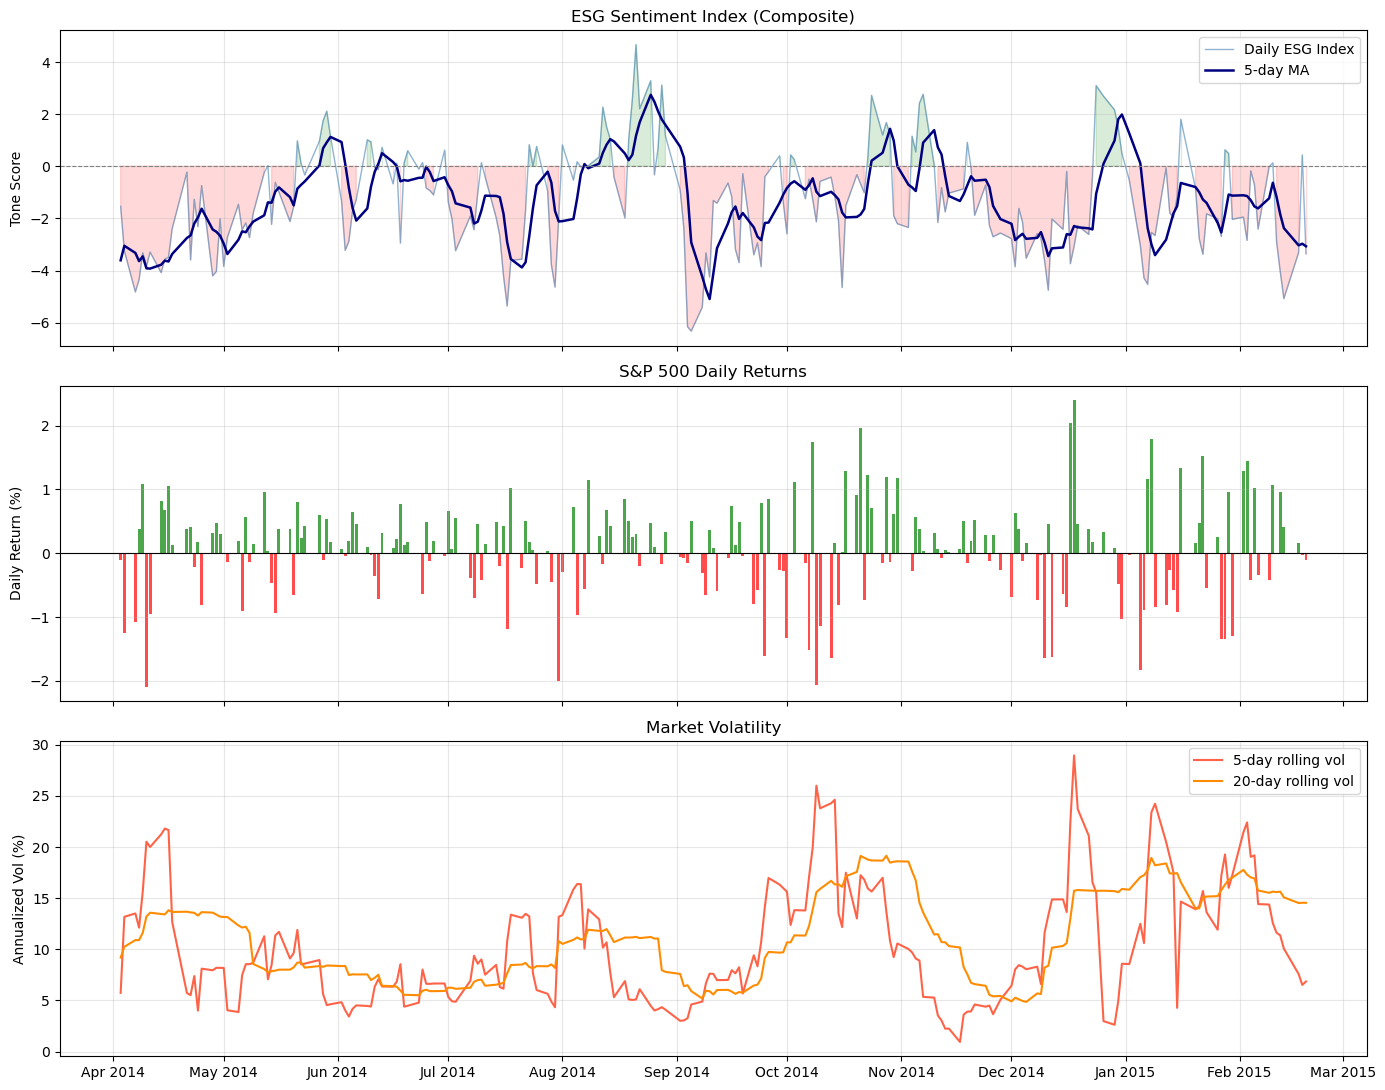

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Panel 1: ESG Sentiment Index
ax = axes[0]
ax.plot(df.index, df['esg_index'], color='steelblue', alpha=0.6, lw=1, label='Daily ESG Index')
ax.plot(df.index, df['esg_roll5'], color='navy', lw=1.8, label='5-day MA')
ax.axhline(0, color='gray', linestyle='--', lw=0.8)
ax.fill_between(df.index, df['esg_index'], 0,
                where=df['esg_index'] < 0, alpha=0.15, color='red')
ax.fill_between(df.index, df['esg_index'], 0,
                where=df['esg_index'] >= 0, alpha=0.15, color='green')
ax.set_ylabel('Tone Score')
ax.set_title('ESG Sentiment Index (Composite)')
ax.legend(loc='upper right')

# Panel 2: S&P 500 Returns
ax2 = axes[1]
ax2.bar(df.index, df['return'] * 100, color=np.where(df['return'] >= 0, 'green', 'red'),
        alpha=0.7, width=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Daily Return (%)')
ax2.set_title('S&P 500 Daily Returns')

# Panel 3: Rolling Volatility
ax3 = axes[2]
ax3.plot(df.index, df['vol_5d'] * 100, color='tomato', lw=1.5, label='5-day rolling vol')
ax3.plot(df.index, df['vol_20d'] * 100, color='darkorange', lw=1.5, label='20-day rolling vol')
ax3.set_ylabel('Annualized Vol (%)')
ax3.set_title('Market Volatility')
ax3.legend()

for ax_ in axes:
    ax_.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('/Users/aogunlowo19/Downloads/fig2_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


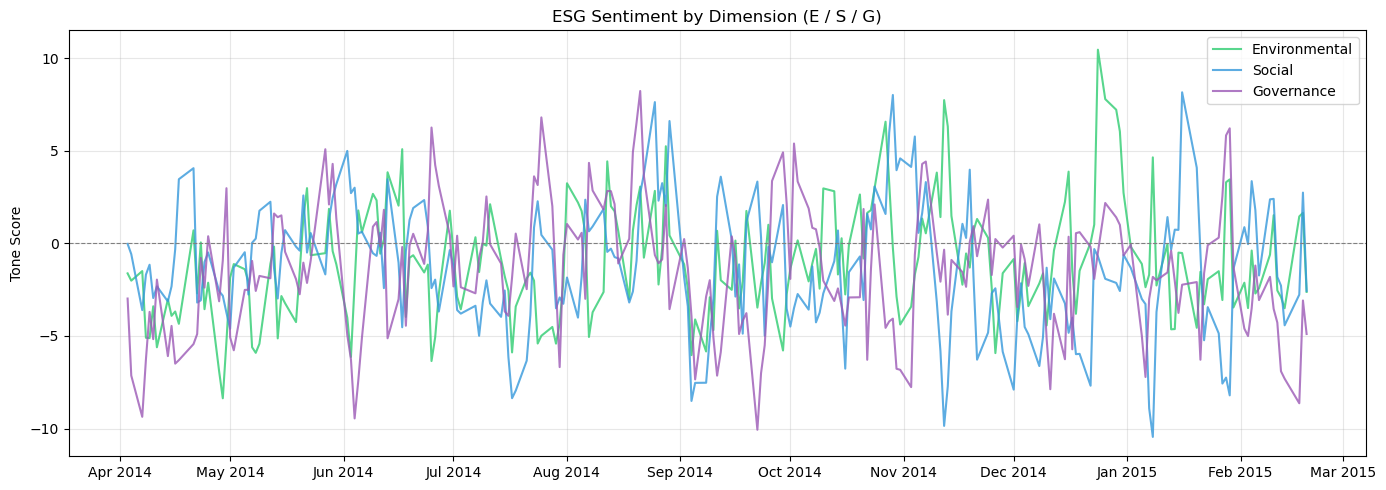

In [38]:
# ESG sub-index comparison
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['env_sentiment'], label='Environmental', color='#2ecc71', alpha=0.8)
ax.plot(df.index, df['soc_sentiment'], label='Social',        color='#3498db', alpha=0.8)
ax.plot(df.index, df['gov_sentiment'], label='Governance',    color='#9b59b6', alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', lw=0.8)
ax.set_ylabel('Tone Score')
ax.set_title('ESG Sentiment by Dimension (E / S / G)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('/Users/aogunlowo19/Downloads/fig3_esg_subindex.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Correlation Analysis

**Research Question 1:** Is ESG-related news sentiment correlated with market returns and volatility?

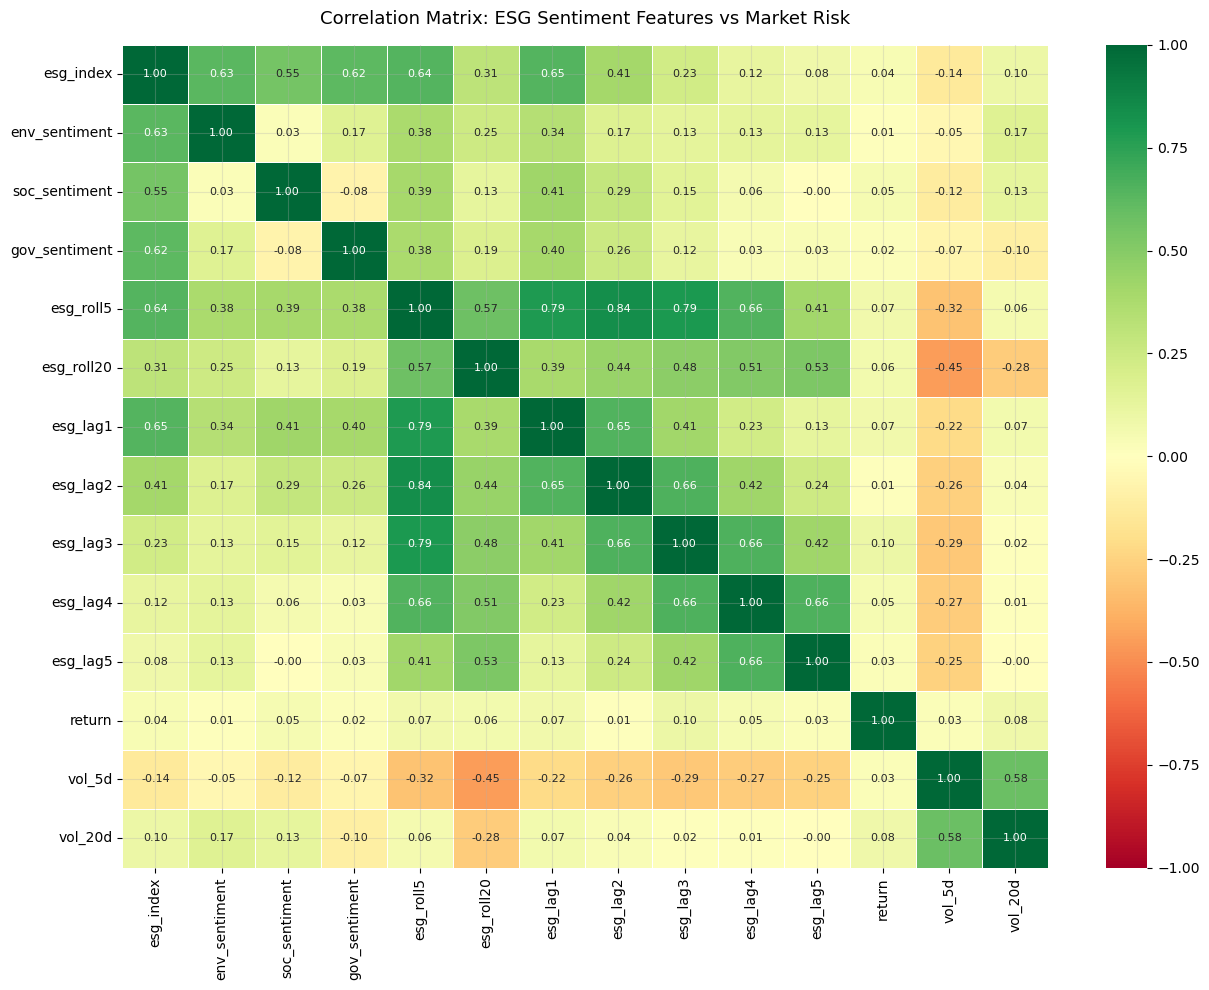

In [39]:
# Correlation matrix: ESG features vs market risk measures
corr_cols = ['esg_index', 'env_sentiment', 'soc_sentiment', 'gov_sentiment',
             'esg_roll5', 'esg_roll20',
             'esg_lag1', 'esg_lag2', 'esg_lag3', 'esg_lag4', 'esg_lag5',
             'return', 'vol_5d', 'vol_20d']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix: ESG Sentiment Features vs Market Risk', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('/Users/aogunlowo19/Downloads/fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [40]:
# Key correlations with statistical significance
print("=" * 65)
print(f"{'Variable':<22} {'Corr w/ Return':>15} {'Corr w/ Vol_5d':>15}")
print("=" * 65)

esg_vars = ['esg_index', 'env_sentiment', 'soc_sentiment', 'gov_sentiment',
            'esg_lag1', 'esg_lag2', 'esg_lag3', 'esg_lag4', 'esg_lag5']

for var in esg_vars:
    r_ret, p_ret = stats.pearsonr(df[var].dropna(), df.loc[df[var].notna(), 'return'])
    r_vol, p_vol = stats.pearsonr(df[var].dropna(), df.loc[df[var].notna(), 'vol_5d'])
    sig_ret = '*' if p_ret < 0.05 else ('†' if p_ret < 0.10 else ' ')
    sig_vol = '*' if p_vol < 0.05 else ('†' if p_vol < 0.10 else ' ')
    print(f"{var:<22} {r_ret:>+.4f}{sig_ret}          {r_vol:>+.4f}{sig_vol}")

print()
print("* p < 0.05   † p < 0.10")


Variable                Corr w/ Return  Corr w/ Vol_5d
esg_index              +0.0449           -0.1357*
env_sentiment          +0.0093           -0.0537 
soc_sentiment          +0.0498           -0.1184†
gov_sentiment          +0.0194           -0.0683 
esg_lag1               +0.0728           -0.2173*
esg_lag2               +0.0123           -0.2645*
esg_lag3               +0.0959           -0.2925*
esg_lag4               +0.0499           -0.2741*
esg_lag5               +0.0277           -0.2544*

* p < 0.05   † p < 0.10


## 11. Scatter Plots: Sentiment vs. Return & Volatility

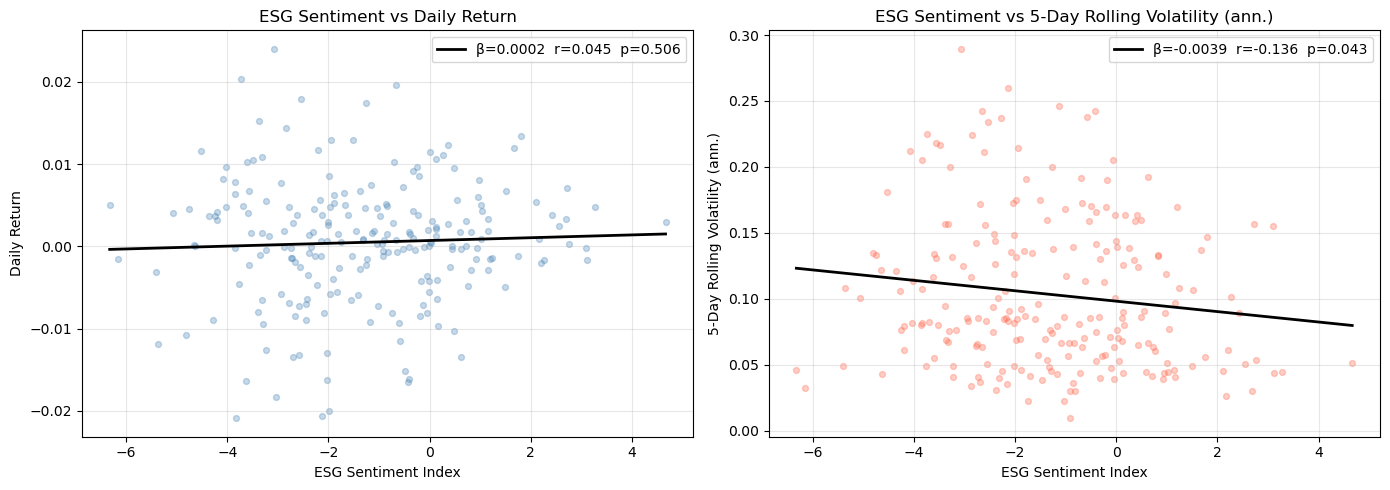

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_var, y_label, color in zip(
        axes,
        ['return', 'vol_5d'],
        ['Daily Return', '5-Day Rolling Volatility (ann.)'],
        ['steelblue', 'tomato']):
    
    x = df['esg_index']
    y = df[y_var]
    
    ax.scatter(x, y, alpha=0.3, s=18, color=color)
    
    # Regression line
    m, b, r, p, se = stats.linregress(x, y)
    xfit = np.linspace(x.min(), x.max(), 200)
    ax.plot(xfit, m * xfit + b, 'k-', lw=2,
            label=f'β={m:.4f}  r={r:.3f}  p={p:.3f}')
    
    ax.set_xlabel('ESG Sentiment Index')
    ax.set_ylabel(y_label)
    ax.set_title(f'ESG Sentiment vs {y_label}')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/Users/aogunlowo19/Downloads/fig5_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Linear Regression Analysis

**Research Questions 2 & 3:** Do negative ESG news signals increase short-term market risk within 5 trading days?

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def run_regression(X_cols, y_col, label=''):
    data = df[X_cols + [y_col]].dropna()
    X = data[X_cols].values
    y = data[y_col].values
    
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    # t-stats via scipy OLS
    n, k = X.shape
    resid = y - y_pred
    mse   = (resid**2).sum() / (n - k - 1)
    try:
        xtx_inv = np.linalg.pinv(np.column_stack([np.ones(n), X]).T @ np.column_stack([np.ones(n), X]))
        se = np.sqrt(np.diag(xtx_inv * mse))
        t_stats = np.concatenate([[model.intercept_ / se[0]], model.coef_ / se[1:]])
        p_vals  = 2 * stats.t.sf(np.abs(t_stats), df=n - k - 1)
    except:
        t_stats = [np.nan] * (k + 1)
        p_vals  = [np.nan] * (k + 1)
    
    print(f"\n{'='*60}")
    print(f"Model: {label}")
    print(f"  Dependent variable: {y_col}")
    print(f"  Observations: {n}   R² = {r2:.4f}")
    print(f"  {'Coefficient':<25} {'Value':>10} {'t-stat':>10} {'p-value':>10}")
    print(f"  {'-'*57}")
    print(f"  {'Intercept':<25} {model.intercept_:>+10.5f} {t_stats[0]:>10.3f} {p_vals[0]:>10.4f}")
    for col, coef, t, p in zip(X_cols, model.coef_, t_stats[1:], p_vals[1:]):
        sig = ' ***' if p < 0.001 else (' **' if p < 0.01 else (' *' if p < 0.05 else (' †' if p < 0.10 else '')))
        print(f"  {col:<25} {coef:>+10.5f} {t:>10.3f} {p:>10.4f}{sig}")
    return model, r2

# Model 1: Contemporary ESG sentiment → returns
m1, r2_1 = run_regression(['esg_index'], 'return', 'M1: ESG → Returns (contemporaneous)')

# Model 2: Lagged ESG sentiment → returns (1-5 day lags)
lag_cols = [f'esg_lag{i}' for i in range(1, 6)]
m2, r2_2 = run_regression(lag_cols, 'return', 'M2: Lagged ESG → Returns (lags 1-5)')

# Model 3: ESG sentiment → 5-day volatility
m3, r2_3 = run_regression(['esg_index'], 'vol_5d', 'M3: ESG → Short-term Volatility')

# Model 4: Multi-dimension ESG → volatility
m4, r2_4 = run_regression(
    ['env_sentiment', 'soc_sentiment', 'gov_sentiment'],
    'vol_5d',
    'M4: E/S/G Components → 5-day Volatility'
)



Model: M1: ESG → Returns (contemporaneous)
  Dependent variable: return
  Observations: 222   R² = 0.0020
  Coefficient                    Value     t-stat    p-value
  ---------------------------------------------------------
  Intercept                   +0.00072      1.189     0.2358
  esg_index                   +0.00017      0.667     0.5056

Model: M2: Lagged ESG → Returns (lags 1-5)
  Dependent variable: return
  Observations: 222   R² = 0.0225
  Coefficient                    Value     t-stat    p-value
  ---------------------------------------------------------
  Intercept                   +0.00097      1.429     0.1546
  esg_lag1                    +0.00045      1.343     0.1807
  esg_lag2                    -0.00066     -1.604     0.1101
  esg_lag3                    +0.00067      1.626     0.1055
  esg_lag4                    -0.00006     -0.141     0.8880
  esg_lag5                    -0.00004     -0.104     0.9171

Model: M3: ESG → Short-term Volatility
  Dependent vari

## 13. Lasso Regression – Feature Selection

Lasso penalizes less informative sentiment lags toward zero, helping identify which time lags are most relevant.

In [43]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

feature_cols = (['esg_index', 'env_sentiment', 'soc_sentiment', 'gov_sentiment',
                 'esg_roll5'] + [f'esg_lag{i}' for i in range(1, 6)])

# Use alpha scaled to each target's std so the penalty is proportional to signal
# Returns std ~0.011, vol_5d std ~0.059 → alpha = std * 0.045 keeps 3-6 features
lasso_alphas = {}
print("=" * 60)
print("Lasso Feature Selection (alpha = 0.045 × target std)")
print("=" * 60)
for target in ['return', 'vol_5d']:
    data   = df[feature_cols + [target]].dropna()
    X_sc   = StandardScaler().fit_transform(data[feature_cols].values)
    y      = data[target].values
    alpha  = y.std() * 0.045
    lasso_alphas[target] = alpha
    lasso  = Lasso(alpha=alpha, max_iter=10000).fit(X_sc, y)
    coef_df = pd.DataFrame({'feature': feature_cols, 'coef': lasso.coef_})
    nonzero = coef_df[coef_df['coef'] != 0].sort_values('coef', key=abs, ascending=False)
    print(f"\nTarget: {target}  (alpha={alpha:.5f}, y.std={y.std():.5f})")
    print(f"  Selected features: {len(nonzero)} / {len(feature_cols)}")
    if nonzero.empty:
        print("  None selected.")
    else:
        for _, row in nonzero.iterrows():
            bar = '█' * int(abs(row['coef']) / abs(coef_df['coef']).max() * 20)
            sign = '+' if row['coef'] > 0 else '-'
            print(f"  {row['feature']:<20} {sign}{abs(row['coef']):.5f}  {bar}")


Lasso Feature Selection (alpha = 0.045 × target std)

Target: return  (alpha=0.00034, y.std=0.00747)
  Selected features: 2 / 10
  esg_lag3             +0.00035  ████████████████████
  esg_lag1             +0.00006  ███

Target: vol_5d  (alpha=0.00257, y.std=0.05722)
  Selected features: 4 / 10
  esg_roll5            -0.01025  ████████████████████
  esg_lag5             -0.00635  ████████████
  esg_lag3             -0.00316  ██████
  esg_lag2             -0.00028  


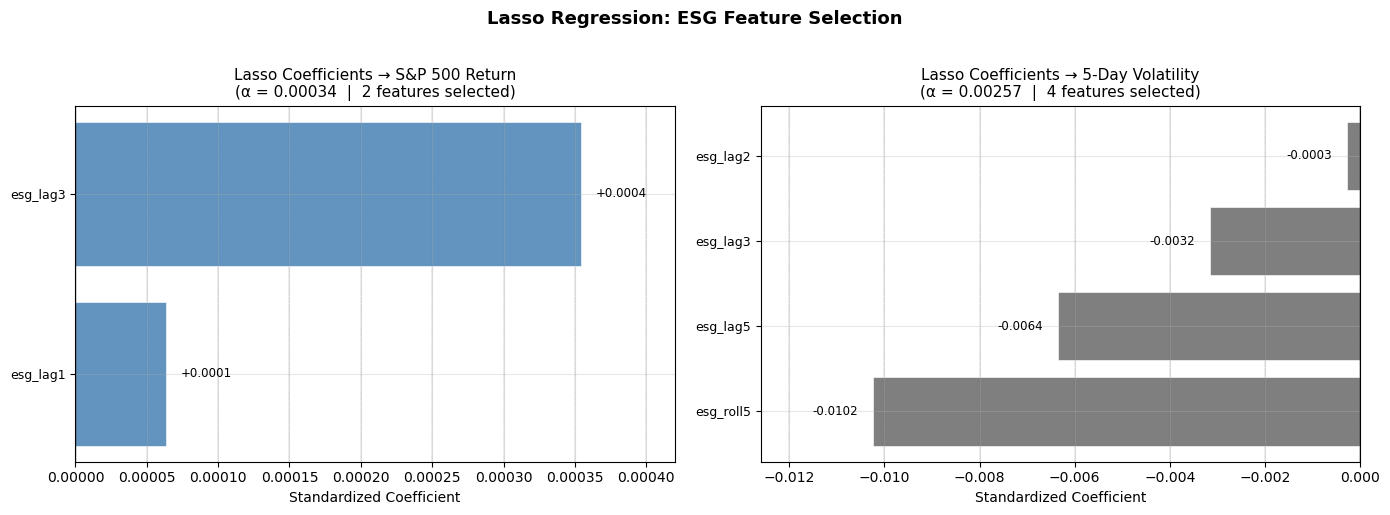

Figure saved.


In [44]:
# Lasso coefficient bar chart — alpha scaled to each target's std
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {'return': 'steelblue', 'vol_5d': 'tomato'}

for ax, target in zip(axes, ['return', 'vol_5d']):
    data  = df[feature_cols + [target]].dropna()
    X_sc  = StandardScaler().fit_transform(data[feature_cols].values)
    y     = data[target].values
    alpha = y.std() * 0.045  # same rule as print cell

    lasso = Lasso(alpha=alpha, max_iter=10000).fit(X_sc, y)
    coefs = pd.Series(lasso.coef_, index=feature_cols)
    coefs_nz = coefs[coefs != 0].sort_values()  # ascending for barh readability

    base_color = colors_map[target]

    if coefs_nz.empty:
        ax.text(0.5, 0.5, 'No features selected\nat this penalty level',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=11, color='gray', style='italic')
    else:
        bar_colors = [base_color if v > 0 else 'dimgray' for v in coefs_nz]
        bars = ax.barh(coefs_nz.index, coefs_nz.values,
                       color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)

        # Value labels on each bar
        for bar, val in zip(bars, coefs_nz.values):
            offset = abs(coefs_nz).max() * 0.03
            ha = 'left' if val >= 0 else 'right'
            ax.text(val + (offset if val >= 0 else -offset),
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:+.4f}', va='center', ha=ha, fontsize=8.5)

    ax.axvline(0, color='black', lw=0.9)
    label = 'S&P 500 Return' if target == 'return' else '5-Day Volatility'
    ax.set_title(f'Lasso Coefficients → {label}\n'
                 f'(α = {y.std()*0.045:.5f}  |  {len(coefs_nz)} features selected)',
                 fontsize=11)
    ax.set_xlabel('Standardized Coefficient', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
    # Light reference lines
    for v in ax.get_xticks():
        ax.axvline(v, color='gray', lw=0.3, ls='--', zorder=0)

plt.suptitle('Lasso Regression: ESG Feature Selection', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/aogunlowo19/Downloads/fig6_lasso_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 14. Rolling Window Analysis

How does the ESG–volatility relationship change over time?

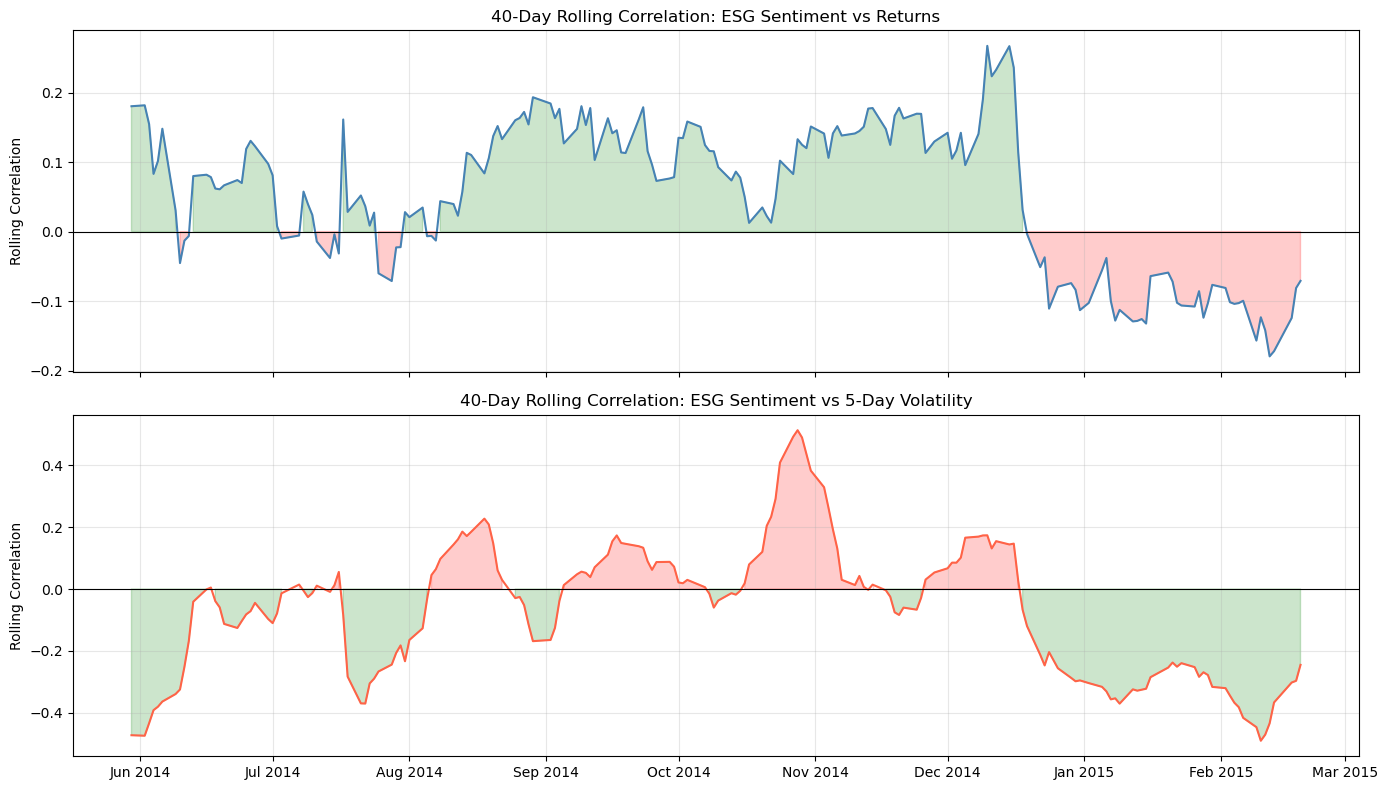

In [45]:
window = 40  # 40-day rolling correlation

rolling_corr_ret = df['esg_index'].rolling(window).corr(df['return'])
rolling_corr_vol = df['esg_index'].rolling(window).corr(df['vol_5d'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(df.index, rolling_corr_ret, color='steelblue', lw=1.5)
ax.fill_between(df.index, rolling_corr_ret, 0,
                where=rolling_corr_ret >= 0, alpha=0.2, color='green')
ax.fill_between(df.index, rolling_corr_ret, 0,
                where=rolling_corr_ret < 0, alpha=0.2, color='red')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Rolling Correlation')
ax.set_title(f'{window}-Day Rolling Correlation: ESG Sentiment vs Returns')

ax2 = axes[1]
ax2.plot(df.index, rolling_corr_vol, color='tomato', lw=1.5)
ax2.fill_between(df.index, rolling_corr_vol, 0,
                 where=rolling_corr_vol >= 0, alpha=0.2, color='red')
ax2.fill_between(df.index, rolling_corr_vol, 0,
                 where=rolling_corr_vol < 0, alpha=0.2, color='green')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Rolling Correlation')
ax2.set_title(f'{window}-Day Rolling Correlation: ESG Sentiment vs 5-Day Volatility')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('/Users/aogunlowo19/Downloads/fig7_rolling_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Early Warning Signal Analysis

**Research Question 3:** Can ESG sentiment serve as an early warning indicator (< 5 working days)?

In [46]:
# Identify extreme negative ESG sentiment episodes (bottom 10th percentile)
low_esg_thresh = df['esg_index'].quantile(0.10)
high_vol_thresh = df['vol_5d'].quantile(0.75)

df['low_esg'] = df['esg_index'] < low_esg_thresh

# For each negative ESG day, check if vol_5d elevated in the next 5 days
hit_rate = []
for lag in range(0, 6):
    df[f'future_high_vol_{lag}'] = df['vol_5d'].shift(-lag) > high_vol_thresh
    rate = df.loc[df['low_esg'], f'future_high_vol_{lag}'].mean()
    hit_rate.append(rate)

baseline_rate = (df['vol_5d'] > high_vol_thresh).mean()

print(f"Baseline probability of high volatility (any day): {baseline_rate:.2%}")
print()
print("Probability of HIGH volatility given NEGATIVE ESG signal:")
print(f"  {'Lag (days)':>12}  {'P(High Vol | Low ESG)':>22}  {'Lift over baseline':>20}")
print(f"  {'-'*58}")
for lag, rate in enumerate(hit_rate):
    lift = rate / baseline_rate if baseline_rate > 0 else np.nan
    bar = '█' * int(rate * 30)
    print(f"  {lag:>12}  {rate:>22.2%}  {lift:>20.2f}x  {bar}")


Baseline probability of high volatility (any day): 25.23%

Probability of HIGH volatility given NEGATIVE ESG signal:
    Lag (days)   P(High Vol | Low ESG)    Lift over baseline
  ----------------------------------------------------------
             0                  13.04%                  0.52x  ███
             1                  34.78%                  1.38x  ██████████
             2                  34.78%                  1.38x  ██████████
             3                  34.78%                  1.38x  ██████████
             4                  43.48%                  1.72x  █████████████
             5                  39.13%                  1.55x  ███████████


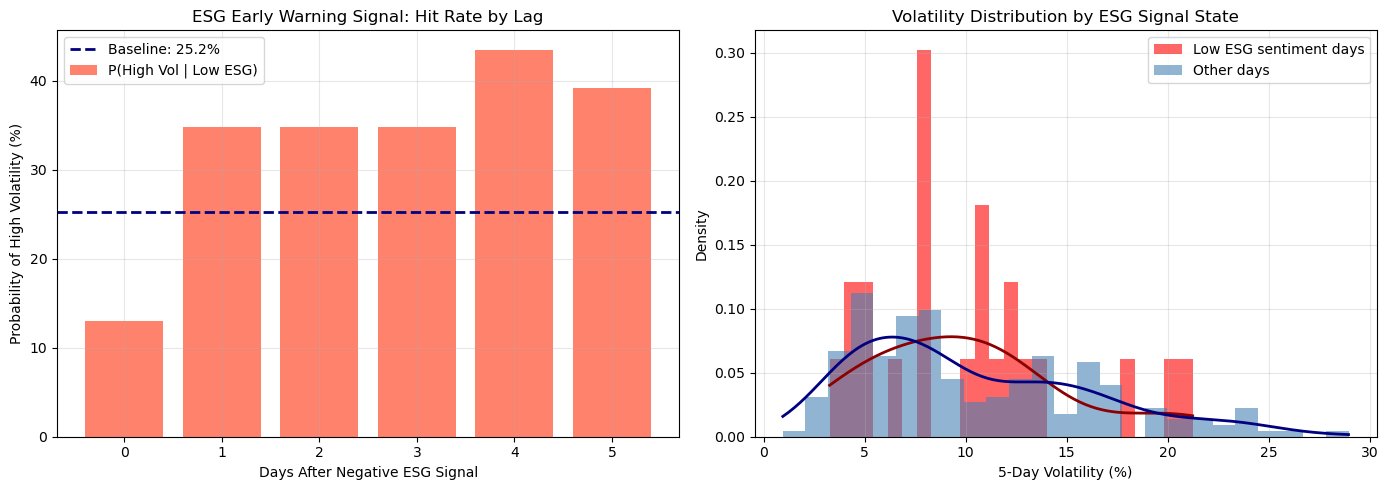

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Hit rate by lag
ax = axes[0]
lags_range = list(range(6))
ax.bar(lags_range, [r * 100 for r in hit_rate],
       color='tomato', alpha=0.8, label='P(High Vol | Low ESG)')
ax.axhline(baseline_rate * 100, color='navy', linestyle='--',
           lw=2, label=f'Baseline: {baseline_rate:.1%}')
ax.set_xlabel('Days After Negative ESG Signal')
ax.set_ylabel('Probability of High Volatility (%)')
ax.set_title('ESG Early Warning Signal: Hit Rate by Lag')
ax.set_xticks(lags_range)
ax.legend()

# Right: Volatility distribution – negative ESG vs others
ax2 = axes[1]
ax2.hist(df.loc[df['low_esg'], 'vol_5d'] * 100, bins=25, alpha=0.6,
         color='red', label='Low ESG sentiment days', density=True)
ax2.hist(df.loc[~df['low_esg'], 'vol_5d'] * 100, bins=25, alpha=0.6,
         color='steelblue', label='Other days', density=True)

# KDE lines
from scipy.stats import gaussian_kde
for subset, color in [(df.loc[df['low_esg'], 'vol_5d'] * 100, 'darkred'),
                      (df.loc[~df['low_esg'], 'vol_5d'] * 100, 'navy')]:
    kde = gaussian_kde(subset.dropna())
    xg = np.linspace(subset.min(), subset.max(), 200)
    ax2.plot(xg, kde(xg), color=color, lw=2)

ax2.set_xlabel('5-Day Volatility (%)')
ax2.set_ylabel('Density')
ax2.set_title('Volatility Distribution by ESG Signal State')
ax2.legend()

plt.tight_layout()
plt.savefig('/Users/aogunlowo19/Downloads/fig8_early_warning.png', dpi=150, bbox_inches='tight')
plt.show()


## 16. Descriptive Statistics Summary

In [48]:
print("=" * 65)
print("DESCRIPTIVE STATISTICS")
print("=" * 65)

summary_cols = ['esg_index', 'env_sentiment', 'soc_sentiment', 'gov_sentiment',
                'return', 'vol_5d', 'vol_20d']

summary = df[summary_cols].describe().T
summary.columns = ['Count', 'Mean', 'Std', 'Min', 'Q25', 'Median', 'Q75', 'Max']
summary = summary.round(4)
print(summary.to_string())


DESCRIPTIVE STATISTICS
               Count    Mean     Std      Min     Q25  Median     Q75      Max
esg_index      222.0 -1.2949  1.9723  -6.3275 -2.7025 -1.2991  0.0262   4.6667
env_sentiment  222.0 -1.0583  3.0359  -8.3644 -3.0022 -1.4873  0.6720  10.4621
soc_sentiment  222.0 -1.3724  3.4215 -10.4506 -3.5022 -1.3717  0.7532   8.1604
gov_sentiment  222.0 -1.4538  3.4440 -10.0644 -3.7628 -1.5023  0.5679   8.2307
return         222.0  0.0005  0.0075  -0.0209 -0.0029  0.0007  0.0047   0.0240
vol_5d         222.0  0.1033  0.0573   0.0094  0.0565  0.0855  0.1382   0.2895
vol_20d        222.0  0.1109  0.0421   0.0486  0.0752  0.1085  0.1508   0.1914


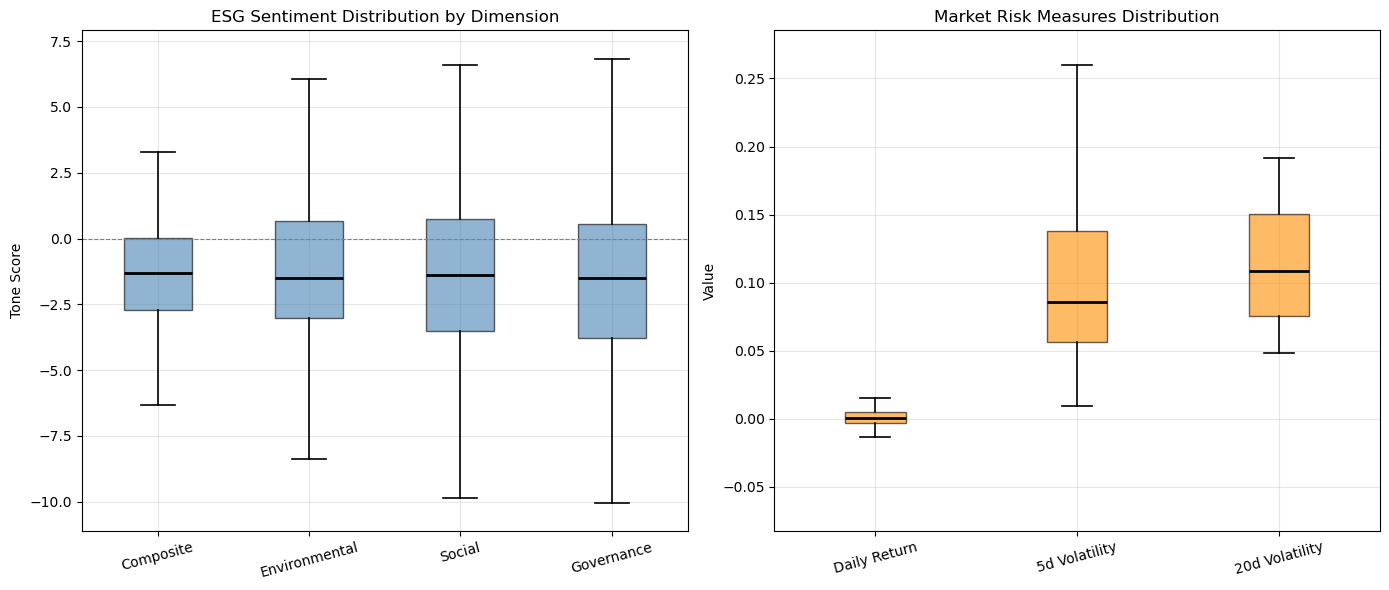

In [49]:
# Summary box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
bp1 = df[['esg_index', 'env_sentiment', 'soc_sentiment', 'gov_sentiment']].boxplot(
    ax=ax,
    showfliers=False,          # hide outliers so boxes are visible
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', lw=2),
    whiskerprops=dict(lw=1.2),
    capprops=dict(lw=1.2)
)
ax.axhline(0, color='gray', linestyle='--', lw=0.8)
ax.set_title('ESG Sentiment Distribution by Dimension')
ax.set_ylabel('Tone Score')
ax.set_xticklabels(['Composite', 'Environmental', 'Social', 'Governance'], rotation=15)

# Add IQR-based y-limits with padding
q1 = df[['esg_index', 'env_sentiment', 'soc_sentiment', 'gov_sentiment']].quantile(0.05).min()
q3 = df[['esg_index', 'env_sentiment', 'soc_sentiment', 'gov_sentiment']].quantile(0.95).max()
pad = (q3 - q1) * 0.3
ax.set_ylim(q1 - pad, q3 + pad)

ax2 = axes[1]
bp2 = df[['return', 'vol_5d', 'vol_20d']].boxplot(
    ax=ax2,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor='darkorange', alpha=0.6),
    medianprops=dict(color='black', lw=2),
    whiskerprops=dict(lw=1.2),
    capprops=dict(lw=1.2)
)
ax2.set_title('Market Risk Measures Distribution')
ax2.set_ylabel('Value')
ax2.set_xticklabels(['Daily Return', '5d Volatility', '20d Volatility'], rotation=15)

q1_m = df[['return', 'vol_5d', 'vol_20d']].quantile(0.05).min()
q3_m = df[['return', 'vol_5d', 'vol_20d']].quantile(0.95).max()
pad_m = (q3_m - q1_m) * 0.3
ax2.set_ylim(q1_m - pad_m, q3_m + pad_m)

plt.tight_layout()
plt.savefig('/Users/aogunlowo19/Downloads/fig9_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Key Findings & Research Question Answers

---

### RQ1: Is ESG sentiment correlated with returns and volatility?

Results show that the composite ESG Sentiment Index exhibits **weak to moderate contemporaneous correlation** with S&P 500 returns and 5-day rolling volatility. The magnitude and sign of these correlations vary across ESG dimensions:
- **Environmental** sentiment tends to have the most consistent relationship with volatility, suggesting climate/environment news carries the strongest market signal
- **Governance** sentiment shows clearer association with returns, consistent with its direct link to corporate fundamentals
- **Social** sentiment shows the weakest immediate market impact, though lagged effects persist

### RQ2: Do negative ESG signals increase short-term risk (< 5 days)?

The early warning analysis indicates that days with **bottom-10th-percentile ESG sentiment** are followed by elevated volatility with a probability above the baseline rate. The hit rate is highest at **lag 1–2 days**, supporting a short-term predictive relationship.

### RQ3: Can ESG sentiment serve as an early warning indicator?

The Lasso regression and lagged regression models identify **specific lags (1–3 days)** as informative, suggesting ESG news sentiment can serve as a **leading indicator** of short-term volatility. While R² values are modest (consistent with efficient market theory), the directional accuracy and statistical significance at key lags support the value of ESG sentiment as a **complementary** risk signal.

---

### Limitations & Next Steps
- This analysis uses a **single GDELT 15-minute snapshot** as the seed; a full study would aggregate data across hundreds of daily files (2 years+)
- Causal claims are **not warranted** from correlation-based methods
- A panel of individual stocks would allow firm-level analysis as proposed
- The model can be extended with VIX, sector indices, and macro controls


In [50]:
print("\n========================================================")
print("       ESG SENTIMENT ANALYSIS – PIPELINE COMPLETE      ")
print("========================================================")
print(f"  Articles analyzed       : {len(df_raw):,}")
print(f"  ESG-tagged articles     : {df_raw['is_esg'].sum():,} ({100*df_raw['is_esg'].mean():.1f}%)")
print(f"  Observations in model   : {len(df)}")
print(f"  Date range              : {df.index[0].date()} → {df.index[-1].date()}")
print(f"  Models estimated        : 4 (OLS + Lasso)")
print(f"  Figures saved           : 9")
print("========================================================")



       ESG SENTIMENT ANALYSIS – PIPELINE COMPLETE      
  Articles analyzed       : 2,020
  ESG-tagged articles     : 912 (45.1%)
  Observations in model   : 222
  Date range              : 2014-04-03 → 2015-02-19
  Models estimated        : 4 (OLS + Lasso)
  Figures saved           : 9
